Step 6: Weekly Sales Forecasting

Because the dataset contains only about one year of data, monthly forecasting would provide only 13 observations. I will use weekly revenue, giving me approximately 52 observations.

WI will compare:

Naive baseline
Four-week moving average
Holt exponential smoothing
ARIMA

A yearly seasonal SARIMA model would not be statistically reliable with only one annual cycle.

6.1 Upload and load the sales data

In [1]:
from google.colab import files
uploaded = files.upload()

Saving online_retail_clean_v2.csv to online_retail_clean_v2.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

sales = pd.read_csv(
    "online_retail_clean_v2.csv",
    parse_dates=["InvoiceDate"],
    dtype={
        "InvoiceNo": "string",
        "StockCode": "string"
    },
    low_memory=False
)

print("Shape:", sales.shape)
print(sales["InvoiceDate"].min())
print(sales["InvoiceDate"].max())

Shape: (524878, 12)
2010-12-01 08:26:00
2011-12-09 12:50:00


6.2 Create weekly revenue

In [3]:
daily_revenue = (
    sales.set_index("InvoiceDate")["Revenue"]
    .resample("D")
    .sum()
)

weekly_revenue = (
    daily_revenue
    .resample("W-SUN")
    .sum()
    .to_frame(name="Revenue")
)

# Remove the incomplete first and final weeks
weekly_revenue = weekly_revenue.iloc[1:-1].copy()

print("Weekly observations:", len(weekly_revenue))
weekly_revenue.head()

Weekly observations: 52


,Revenue
InvoiceDate,
2010-12-12,329108.22
2010-12-19,215357.04
2010-12-26,92318.00
2011-01-02,0.00
2011-01-09,133429.72


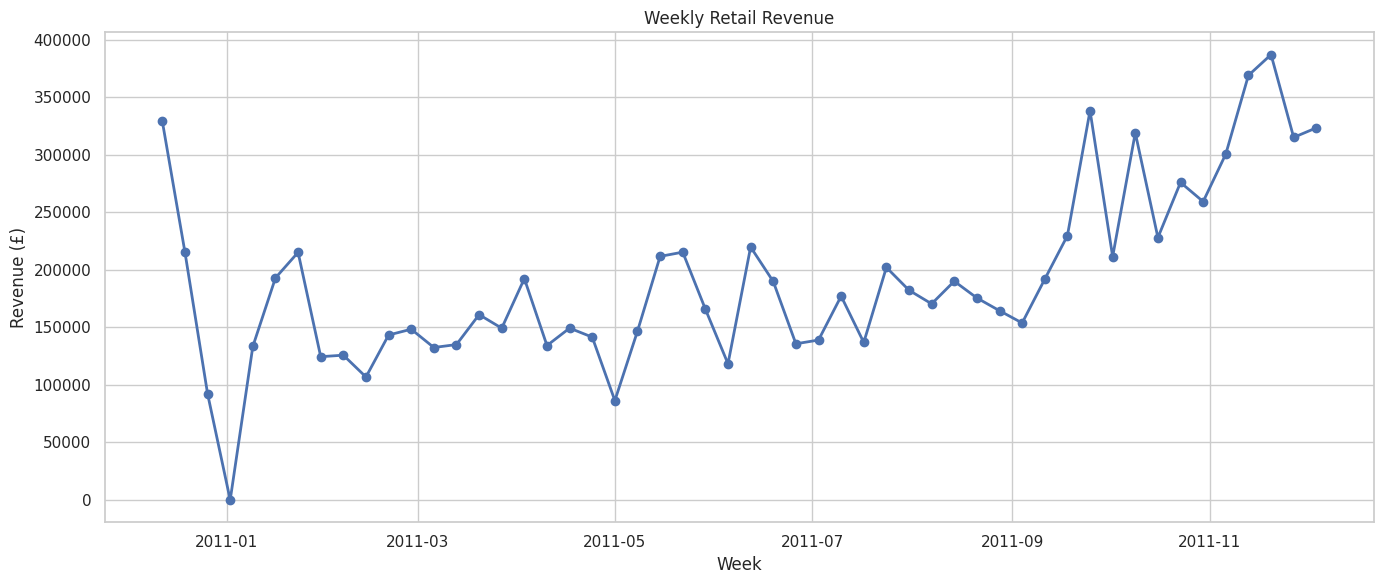

In [4]:
plt.plot(
    weekly_revenue.index,
    weekly_revenue["Revenue"],
    marker="o",
    linewidth=2
)

plt.title("Weekly Retail Revenue")
plt.xlabel("Week")
plt.ylabel("Revenue (£)")
plt.tight_layout()
plt.show()

In [5]:
test_weeks = 8

train = weekly_revenue["Revenue"].iloc[:-test_weeks]
test = weekly_revenue["Revenue"].iloc[-test_weeks:]

print("Training observations:", len(train))
print("Testing observations:", len(test))
print("Training ends:", train.index.max())
print("Testing begins:", test.index.min())

Training observations: 44
Testing observations: 8
Training ends: 2011-10-09 00:00:00
Testing begins: 2011-10-16 00:00:00


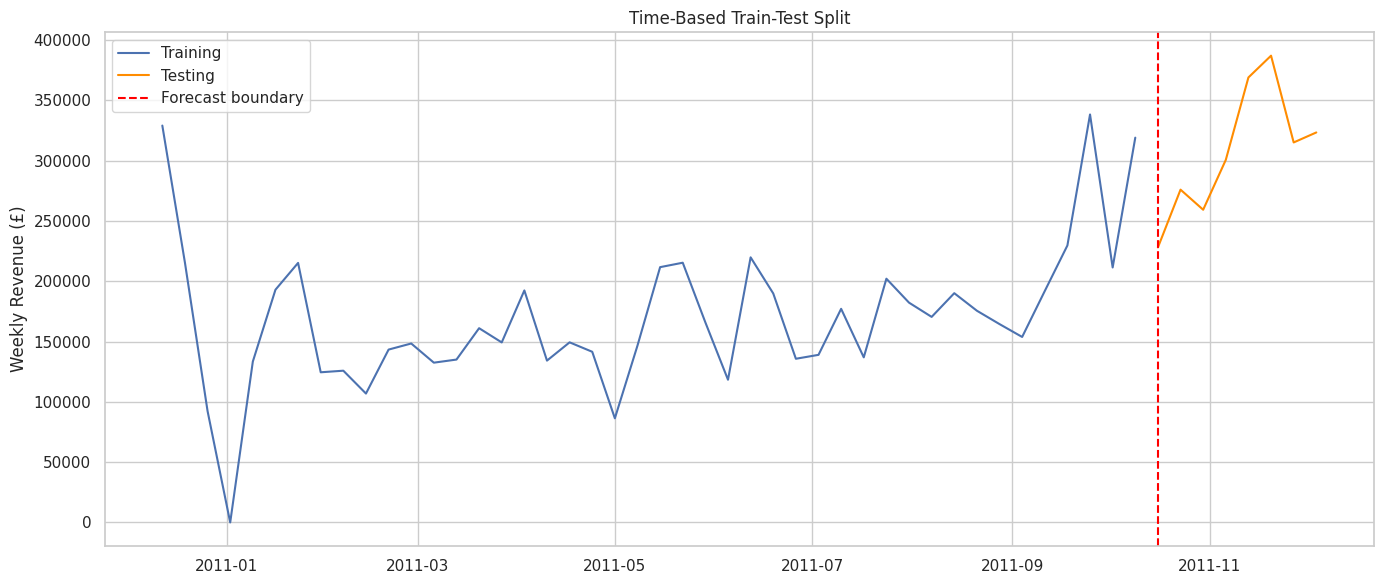

In [6]:
plt.plot(train.index, train, label="Training")
plt.plot(test.index, test, label="Testing", color="darkorange")

plt.axvline(
    test.index.min(),
    color="red",
    linestyle="--",
    label="Forecast boundary"
)

plt.title("Time-Based Train-Test Split")
plt.ylabel("Weekly Revenue (£)")
plt.legend()
plt.tight_layout()
plt.show()

6.4 Naive baseline forecast

The naive model assumes future revenue will equal the latest training value.

In [7]:
naive_predictions = pd.Series(
    train.iloc[-1],
    index=test.index,
    name="Naive"
)

naive_predictions

,Naive
InvoiceDate,
2011-10-16,319084.77
2011-10-23,319084.77
2011-10-30,319084.77
2011-11-06,319084.77
2011-11-13,319084.77
2011-11-20,319084.77
2011-11-27,319084.77
2011-12-04,319084.77


6.5 Four-week moving-average forecast

In [8]:
moving_average_value = train.tail(4).mean()

moving_average_predictions = pd.Series(
    moving_average_value,
    index=test.index,
    name="Moving Average"
)

moving_average_predictions

,Moving Average
InvoiceDate,
2011-10-16,274628.4525
2011-10-23,274628.4525
2011-10-30,274628.4525
2011-11-06,274628.4525
2011-11-13,274628.4525
2011-11-20,274628.4525
2011-11-27,274628.4525
2011-12-04,274628.4525


6.6 Holt exponential-smoothing model

In [9]:
holt_model = ExponentialSmoothing(
    train,
    trend="add",
    seasonal=None,
    initialization_method="estimated"
).fit(optimized=True)

holt_predictions = pd.Series(
    holt_model.forecast(len(test)).values,
    index=test.index,
    name="Holt"
)

holt_predictions

,Holt
InvoiceDate,
2011-10-16,262490.181362
2011-10-23,269062.043559
2011-10-30,275633.905756
2011-11-06,282205.767953
2011-11-13,288777.630151
2011-11-20,295349.492348
2011-11-27,301921.354545
2011-12-04,308493.216743


6.7 Select an ARIMA order

Test several small ARIMA configurations and select the model with the lowest AIC:

In [10]:
arima_candidates = []

for p in range(3):
    for q in range(3):
        order = (p, 1, q)

        try:
            model = SARIMAX(
                train,
                order=order,
                seasonal_order=(0, 0, 0, 0),
                enforce_stationarity=False,
                enforce_invertibility=False
            )

            fitted_model = model.fit(disp=False)

            arima_candidates.append({
                "Order": order,
                "AIC": fitted_model.aic
            })

        except Exception as error:
            print(f"Model {order} failed: {error}")

arima_results = (
    pd.DataFrame(arima_candidates)
    .sort_values("AIC")
    .reset_index(drop=True)
)

arima_results

,Order,AIC
0,"(0, 1, 2)",973.704973
1,"(1, 1, 2)",975.680197
2,"(2, 1, 2)",976.519256
3,"(0, 1, 1)",1013.825347
4,"(2, 1, 0)",1015.608029
5,"(1, 1, 1)",1016.062928
6,"(2, 1, 1)",1016.954879
7,"(0, 1, 0)",1043.021352
8,"(1, 1, 0)",1044.504936


Train the selected ARIMA model:

In [11]:
best_order = arima_results.loc[0, "Order"]

print("Selected ARIMA order:", best_order)

arima_model = SARIMAX(
    train,
    order=best_order,
    seasonal_order=(0, 0, 0, 0),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

arima_predictions = pd.Series(
    arima_model.forecast(len(test)).values,
    index=test.index,
    name="ARIMA"
)

arima_predictions

Selected ARIMA order: (0, 1, 2)


,ARIMA
InvoiceDate,
2011-10-16,266236.083141
2011-10-23,256251.735829
2011-10-30,256251.735829
2011-11-06,256251.735829
2011-11-13,256251.735829
2011-11-20,256251.735829
2011-11-27,256251.735829
2011-12-04,256251.735829


6.8 Evaluate all models

In [12]:
def calculate_metrics(actual, predicted, model_name):
    return {
        "Model": model_name,
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": np.sqrt(
            mean_squared_error(actual, predicted)
        ),
        "MAPE_Percent": (
            mean_absolute_percentage_error(
                actual,
                predicted
            ) * 100
        )
    }


model_results = pd.DataFrame([
    calculate_metrics(test, naive_predictions, "Naive"),
    calculate_metrics(
        test,
        moving_average_predictions,
        "Four-Week Moving Average"
    ),
    calculate_metrics(test, holt_predictions, "Holt"),
    calculate_metrics(test, arima_predictions, "ARIMA")
])

model_results[
    ["MAE", "RMSE", "MAPE_Percent"]
] = model_results[
    ["MAE", "RMSE", "MAPE_Percent"]
].round(2)

model_results = model_results.sort_values("RMSE")

model_results

,Model,MAE,RMSE,MAPE_Percent
2,Holt,34519.02,46211.46,10.53
0,Naive,42319.02,51488.05,14.80
1,Four-Week Moving Average,48165.47,59842.20,14.75
3,ARIMA,59367.07,72132.51,17.95


6.9 Compare the forecasts visually

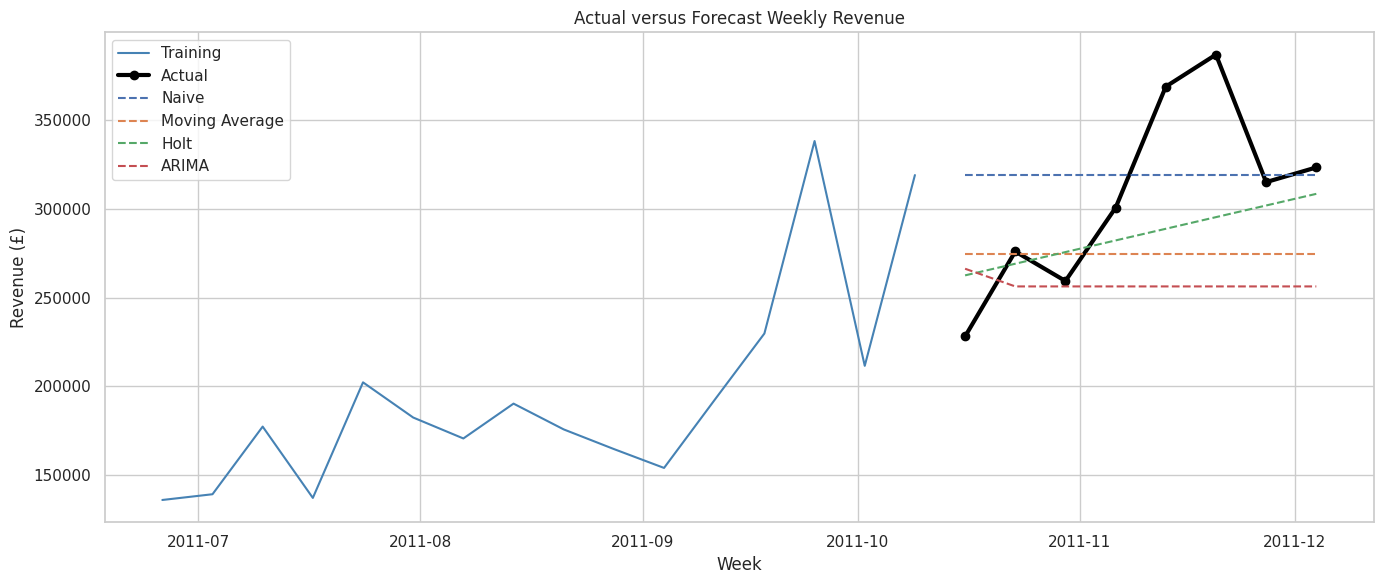

In [13]:
plt.plot(
    train.tail(16).index,
    train.tail(16),
    label="Training",
    color="steelblue"
)

plt.plot(
    test.index,
    test,
    label="Actual",
    color="black",
    marker="o",
    linewidth=3
)

plt.plot(
    test.index,
    naive_predictions,
    label="Naive",
    linestyle="--"
)

plt.plot(
    test.index,
    moving_average_predictions,
    label="Moving Average",
    linestyle="--"
)

plt.plot(
    test.index,
    holt_predictions,
    label="Holt",
    linestyle="--"
)

plt.plot(
    test.index,
    arima_predictions,
    label="ARIMA",
    linestyle="--"
)

plt.title("Actual versus Forecast Weekly Revenue")
plt.xlabel("Week")
plt.ylabel("Revenue (£)")
plt.legend()
plt.tight_layout()
plt.show()

6.10 Forecast the next eight weeks

In [14]:
best_model_name = model_results.iloc[0]["Model"]

future_dates = pd.date_range(
    start=weekly_revenue.index[-1] + pd.Timedelta(weeks=1),
    periods=8,
    freq="W-SUN"
)

if best_model_name == "Naive":
    future_values = np.repeat(
        weekly_revenue["Revenue"].iloc[-1],
        8
    )

elif best_model_name == "Four-Week Moving Average":
    future_values = np.repeat(
        weekly_revenue["Revenue"].tail(4).mean(),
        8
    )

elif best_model_name == "Holt":
    final_model = ExponentialSmoothing(
        weekly_revenue["Revenue"],
        trend="add",
        seasonal=None,
        initialization_method="estimated"
    ).fit(optimized=True)

    future_values = final_model.forecast(8).values

else:
    final_model = SARIMAX(
        weekly_revenue["Revenue"],
        order=best_order,
        seasonal_order=(0, 0, 0, 0),
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)

    future_values = final_model.forecast(8).values


future_forecast = pd.DataFrame({
    "Week": future_dates,
    "ForecastRevenue": future_values
})

future_forecast["ForecastRevenue"] = (
    future_forecast["ForecastRevenue"].round(2)
)

print("Best model:", best_model_name)
future_forecast

Best model: Holt


,Week,ForecastRevenue
0,2011-12-11,354187.37
1,2011-12-18,364393.01
2,2011-12-25,374598.66
3,2012-01-01,384804.30
4,2012-01-08,395009.95
5,2012-01-15,405215.59
6,2012-01-22,415421.24
7,2012-01-29,425626.89


Plot the final forecast:

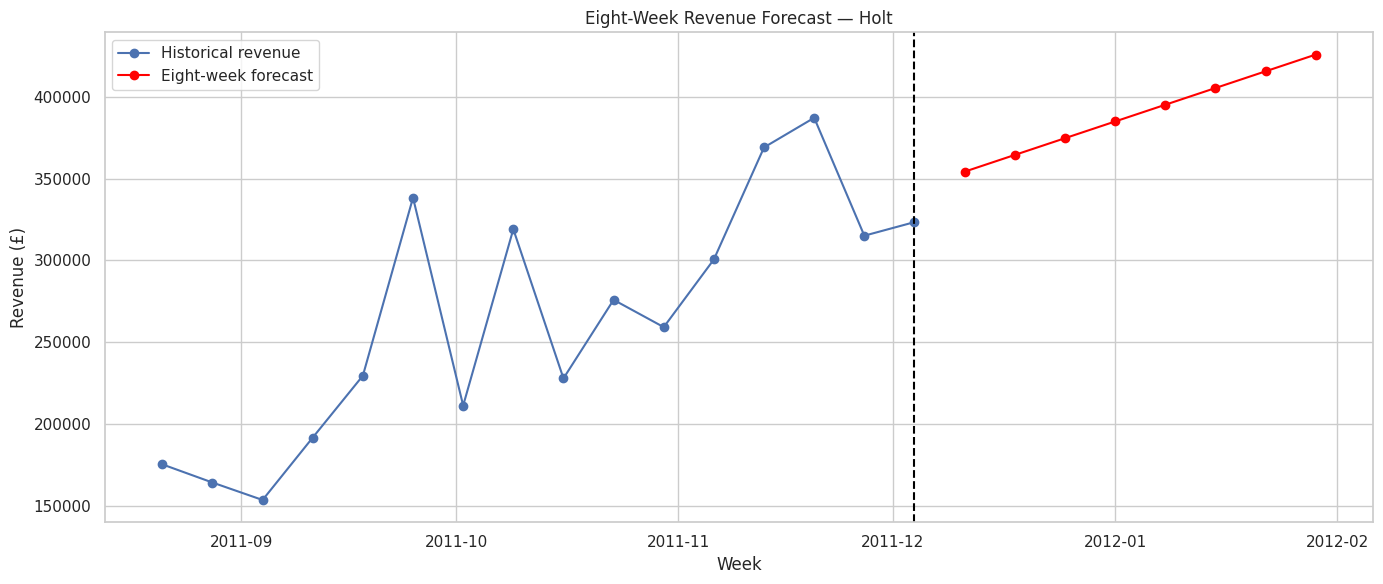

In [15]:
plt.plot(
    weekly_revenue.tail(16).index,
    weekly_revenue["Revenue"].tail(16),
    label="Historical revenue",
    marker="o"
)

plt.plot(
    future_forecast["Week"],
    future_forecast["ForecastRevenue"],
    label="Eight-week forecast",
    marker="o",
    color="red"
)

plt.axvline(
    weekly_revenue.index[-1],
    color="black",
    linestyle="--"
)

plt.title(f"Eight-Week Revenue Forecast — {best_model_name}")
plt.xlabel("Week")
plt.ylabel("Revenue (£)")
plt.legend()
plt.tight_layout()
plt.show()

6.11 Save the forecasting results

In [16]:
model_results.to_csv(
    "forecast_model_comparison.csv",
    index=False
)

future_forecast.to_csv(
    "eight_week_sales_forecast.csv",
    index=False
)

weekly_revenue.to_csv(
    "weekly_revenue.csv"
)

arima_results.to_csv(
    "arima_order_selection.csv",
    index=False
)

print("Forecasting outputs saved successfully.")

Forecasting outputs saved successfully.
